# Oasis Infobyte Internship

## Data Analytics – Level 1

# Customer Segmentation Analysis using K-Means Clustering

### Name:
**Shivanand Prakash Birajdar**

### Objective
The objective of this project is to segment customers based on their purchasing behaviour using RFM (Recency, Frequency, Monetary) analysis and K-Means Clustering. The goal is to identify different customer groups and recommend suitable marketing strategies for each segment.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

%matplotlib inline

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 1: Load Dataset and Initial Inspection

In this step, we load the dataset and perform an initial inspection to understand its structure, dimensions, data types, and missing values.

In [3]:
# Load the dataset
df = pd.read_csv("dataset/online_retail_II.csv", encoding="ISO-8859-1")

# Display first 5 rows
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset: (1067371, 8)

Column Names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data Types:
Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

Missing Values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


### Observation

- The dataset has multiple transaction records from different customers.
- It contains product details, customer information, invoice dates, and purchase values.
- The missing values and data types identified here will be handled in the data cleaning step before performing customer segmentation.

## Step 2: Data Cleaning

Before performing customer segmentation, we need to clean the dataset by:

- Removing missing values
- Removing cancelled transactions
- Removing records with invalid quantity or price
- Creating Total Amount for each transaction
- Converting Invoice Date into datetime format

In [5]:
# Copy original dataset
df_clean = df.copy()

# Remove missing Customer ID
df_clean = df_clean.dropna(subset=["Customer ID"])

# Remove cancelled invoices
df_clean = df_clean[~df_clean["Invoice"].astype(str).str.startswith("C")]

# Remove negative or zero quantity
df_clean = df_clean[df_clean["Quantity"] > 0]

# Remove negative or zero price
df_clean = df_clean[df_clean["Price"] > 0]

# Convert InvoiceDate to datetime
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# Create Total Amount
df_clean["TotalAmount"] = df_clean["Quantity"] * df_clean["Price"]

print("Cleaned Dataset Shape:", df_clean.shape)

df_clean.head()

Cleaned Dataset Shape: (805549, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


### Observation

The dataset has been cleaned by removing cancelled transactions, missing customer IDs, and invalid records. A new feature named **TotalAmount** has been created, which represents the total spending for each transaction.

## Step 3: RFM (Recency, Frequency, Monetary) Analysis

RFM Analysis is used to understand customer purchasing behaviour.

- **Recency (R):** Number of days since the customer's last purchase.
- **Frequency (F):** Total number of purchases made by the customer.
- **Monetary (M):** Total amount spent by the customer.

In [6]:
# Reference date (one day after the last transaction)
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

# Create RFM Table
rfm = df_clean.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "Invoice": "nunique",
    "TotalAmount": "sum"
})

# Rename columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

# Display first 5 rows
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [7]:
print("RFM Shape:", rfm.shape)

print("\nSummary Statistics:")
display(rfm.describe())

RFM Shape: (5878, 3)

Summary Statistics:


,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,3018.616737
std,209.338707,13.009406,14737.731040
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,348.762500
50%,96.000000,3.000000,898.915000
75%,380.000000,7.000000,2307.090000
max,739.000000,398.000000,608821.650000


### Observation

The RFM table has been created successfully. Each customer is represented by:

- Recency: Days since the last purchase
- Frequency: Number of unique invoices
- Monetary: Total spending by the customer

These features will be used for customer segmentation using K-Means clustering.

## Step 4: Data Standardization

The RFM features have different scales. Standardization is performed using StandardScaler to ensure each feature contributes equally during K-Means clustering.

In [8]:
# Standardize RFM features
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

print("Scaled Data Shape:", rfm_scaled.shape)

Scaled Data Shape: (5878, 3)


### Observation

The RFM features have been standardized successfully. The scaled dataset is now ready for K-Means clustering.

## Step 5: Finding the Optimal Number of Clusters (Elbow Method)

The Elbow Method helps determine the optimal number of clusters by plotting WCSS (Within-Cluster Sum of Squares) against different values of K.

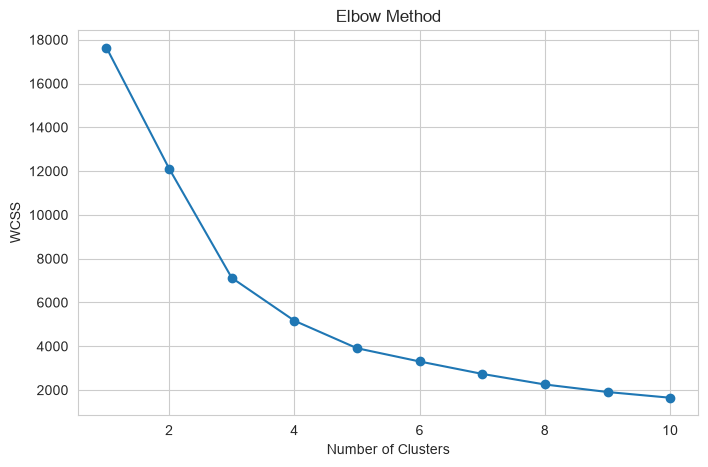

In [9]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

# Save graph
plt.savefig("screenshots/elbow_method.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The elbow point indicates the optimal number of customer clusters for K-Means segmentation.

## Step 6: K-Means Clustering

Using the optimal number of clusters (K = 4), customers are grouped based on their RFM characteristics.

In [10]:
# Apply K-Means with K = 4

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,12,77556.46,1
12347.0,2,8,5633.32,1
12348.0,75,5,2019.40,1
12349.0,19,4,4428.69,1
12350.0,310,1,334.40,0


In [11]:
print("Number of Customers in Each Cluster:")

print(rfm["Cluster"].value_counts().sort_index())

Number of Customers in Each Cluster:
Cluster
0    1998
1    3841
2      35
3       4
Name: count, dtype: int64


### Observation

Customers have been successfully segmented into four different clusters based on their purchasing behaviour using K-Means clustering.

## Step 7: Cluster Visualization

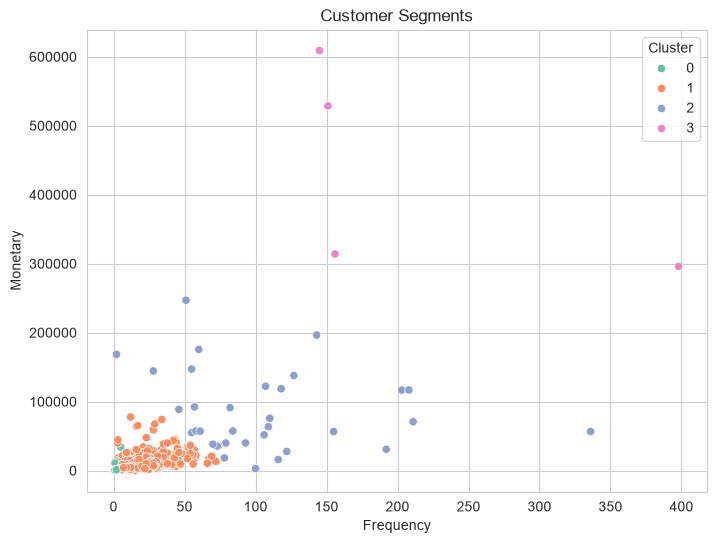

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.savefig("screenshots/customer_segments.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Step 8: Customer Cluster Profile

The average RFM values for each cluster are calculated to understand customer behaviour and identify different customer segments.

In [13]:
# Average RFM values for each cluster

cluster_profile = rfm.groupby("Cluster").mean().round(2)

display(cluster_profile)

,Recency,Frequency,Monetary
Cluster,,,
0,463.03,2.21,765.24
1,67.01,7.31,3009.40
2,25.94,103.71,83086.08
3,3.50,212.50,436835.79


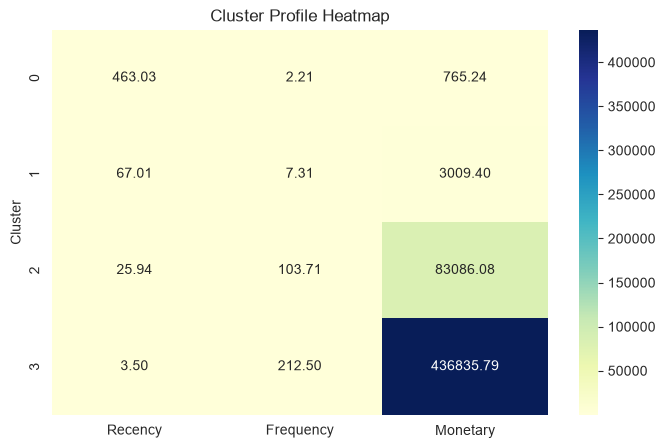

In [14]:
plt.figure(figsize=(8,5))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Cluster Profile Heatmap")

plt.savefig(
    "screenshots/cluster_profile_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The heatmap shows the average Recency, Frequency, and Monetary values for each customer cluster, making it easier to compare customer behaviour across different segments.

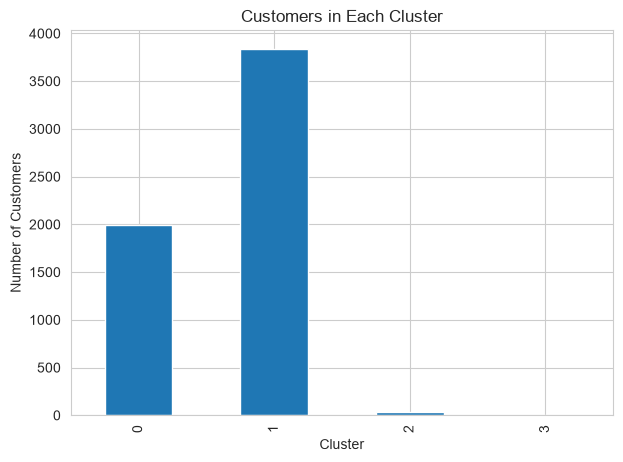

In [15]:
plt.figure(figsize=(7,5))

rfm["Cluster"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.savefig(
    "screenshots/customers_per_cluster.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 9: Business Recommendations

### Recommendation 1
Reward VIP customers (Cluster 3) with exclusive offers, loyalty rewards, and premium services to retain them.

### Recommendation 2
Encourage regular customers (Cluster 1) to purchase more frequently through personalized discounts and promotional campaigns.

### Recommendation 3
Re-engage inactive customers (Cluster 0) using email marketing, special discounts, and seasonal offers.

### Recommendation 4
Provide personalized product recommendations to loyal customers (Cluster 2) to increase customer lifetime value.

# Final Conclusion

Customer Segmentation was successfully performed using RFM Analysis and K-Means Clustering.

The analysis grouped customers into four distinct segments based on Recency, Frequency, and Monetary value.

Key Findings:
- Cluster 0 consists of inactive and low-value customers.
- Cluster 1 represents regular customers with moderate spending.
- Cluster 2 includes loyal customers with high purchase frequency and high spending.
- Cluster 3 contains premium customers who contribute the highest revenue.

This segmentation enables businesses to implement targeted marketing strategies, improve customer retention, and maximize revenue.